# Wine Quality Classification

In this notebook, we build a machine learning model to predict whether a red wine is **good quality** or **not good quality**.

We will:
- Load the dataset directly from a URL
- Explore the data
- Create a binary target from the original quality score
- Split into train and test sets
- Train a baseline Logistic Regression model
- Train a stronger Random Forest model
- Compare performance

This notebook helps revise:
- binary classification
- feature-target separation
- EDA
- scaling numeric data
- model comparison

## 1. Import libraries

We import:
- pandas and numpy for data handling
- matplotlib and seaborn for visualization
- scikit-learn for preprocessing, modeling, and evaluation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set(style="whitegrid")

## 2. Load the dataset from a URL

We use the red wine quality dataset from the UCI Machine Learning Repository.

The dataset contains physicochemical measurements of Portuguese "Vinho Verde" red wine, along with a quality score.

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 3. Basic inspection

We check:
- shape of the dataset
- column names
- missing values
- summary statistics

In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values:\n")
print(df.isnull().sum())

Shape: (1599, 12)

Columns:
 ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Missing values:

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## 4. Understand the target variable

The original target is `quality`, which is an integer score.

To make this notebook simpler for revision, we convert it into a binary classification problem:

- `1` if quality >= 7 → good wine
- `0` if quality < 7 → not good wine

In [5]:
df["good_quality"] = (df["quality"] >= 7).astype(int)

df[["quality", "good_quality"]].head()

,quality,good_quality
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


## 5. Check class distribution

We inspect how many wines fall into each class.

In [6]:
print(df["good_quality"].value_counts())

good_quality
0    1382
1     217
Name: count, dtype: int64


/tmp/ipykernel_5818/2660565200.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="good_quality", data=df, palette="Set2")


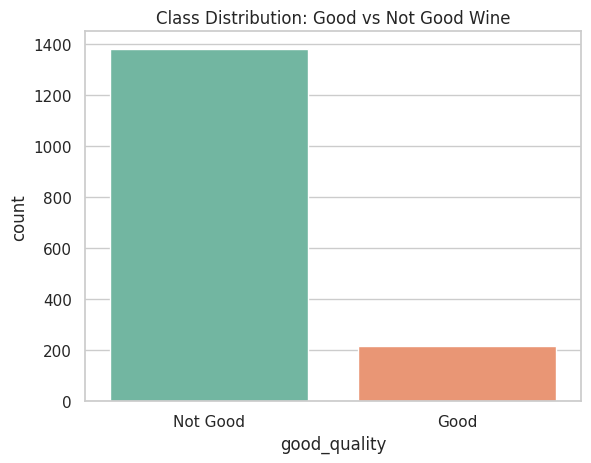

In [7]:
sns.countplot(x="good_quality", data=df, palette="Set2")
plt.title("Class Distribution: Good vs Not Good Wine")
plt.xticks([0, 1], ["Not Good", "Good"])
plt.show()

## 6. Quick EDA

We check:
- correlation with the target
- distribution of quality scores

/tmp/ipykernel_5818/4066867481.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, palette="viridis")


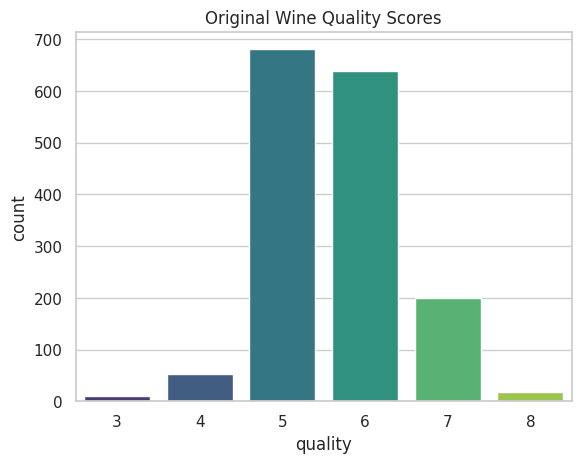

In [8]:
sns.countplot(x="quality", data=df, palette="viridis")
plt.title("Original Wine Quality Scores")
plt.show()

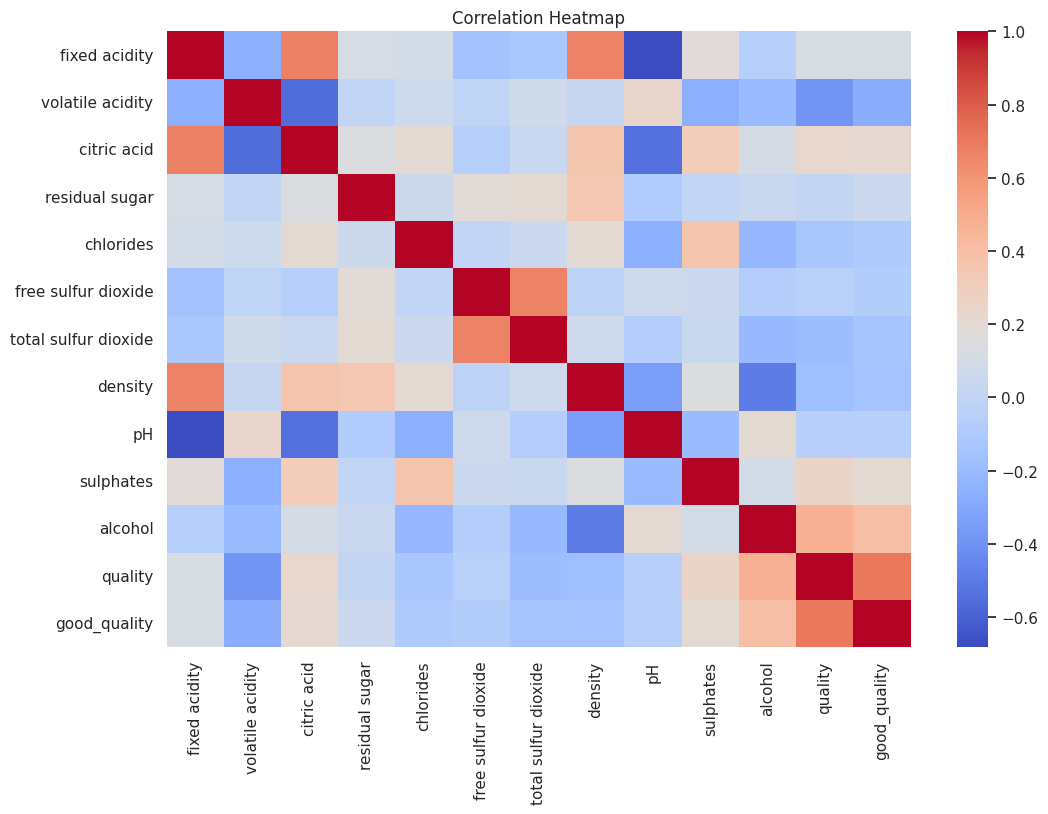

In [9]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

## 7. Separate features and target

We use all original physicochemical variables as features, except the original `quality` column.

Target:
- `good_quality`

In [10]:
X = df.drop(columns=["quality", "good_quality"])
y = df["good_quality"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1599, 11)
y shape: (1599,)


## 8. Train-test split

We split the data into:
- 80% training set
- 20% test set

We stratify by the target because the classes are not perfectly balanced.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (1279, 11)
X_test : (320, 11)


## 9. First model: Logistic Regression

Since all features are numeric, preprocessing is simpler here.

We build a pipeline:
- scale features using `StandardScaler`
- train `LogisticRegression`

In [12]:
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline.fit(X_train, y_train)

y_pred_logreg = logreg_pipeline.predict(X_test)

## 10. Evaluate Logistic Regression

We evaluate using:
- accuracy
- precision
- recall
- F1-score
- confusion matrix

Logistic Regression performance:
Accuracy : 0.8938
Precision: 0.6957
Recall   : 0.3721
F1-score : 0.4848

Classification report:

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       277
           1       0.70      0.37      0.48        43

    accuracy                           0.89       320
   macro avg       0.80      0.67      0.71       320
weighted avg       0.88      0.89      0.88       320



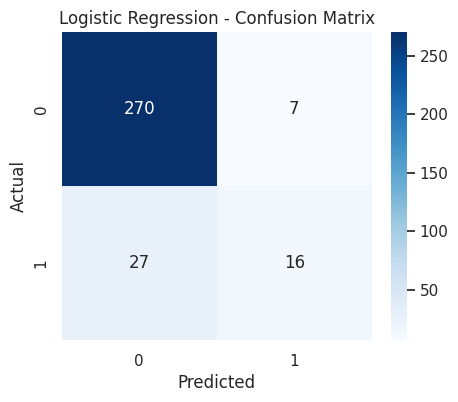

In [13]:
def evaluate_binary(y_true, y_pred, model_name="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"{model_name} performance:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification report:\n")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

evaluate_binary(y_test, y_pred_logreg, model_name="Logistic Regression")

## 11. Second model: Random Forest

Now we try a stronger tree-based model: `RandomForestClassifier`.

Random Forest can capture non-linear relationships and does not depend on linear decision boundaries.

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

## 12. Evaluate Random Forest

Random Forest performance:
Accuracy : 0.9437
Precision: 0.9310
Recall   : 0.6279
F1-score : 0.7500

Classification report:

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       277
           1       0.93      0.63      0.75        43

    accuracy                           0.94       320
   macro avg       0.94      0.81      0.86       320
weighted avg       0.94      0.94      0.94       320



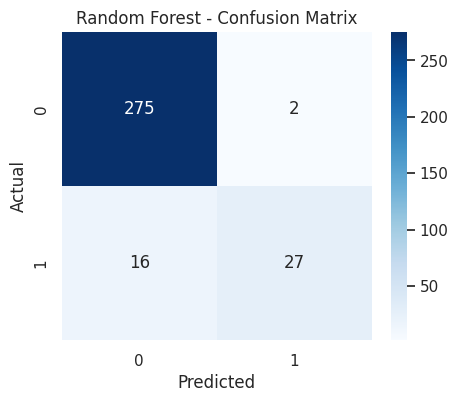

In [15]:
evaluate_binary(y_test, y_pred_rf, model_name="Random Forest")

## 13. Compare both models

We compare Logistic Regression and Random Forest side by side.

In [16]:
def get_scores(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

scores_logreg = get_scores(y_test, y_pred_logreg)
scores_rf = get_scores(y_test, y_pred_rf)

results = pd.DataFrame([scores_logreg, scores_rf],
                       index=["Logistic Regression", "Random Forest"])
results

,Accuracy,Precision,Recall,F1
Logistic Regression,0.89375,0.695652,0.372093,0.484848
Random Forest,0.94375,0.931034,0.627907,0.750000


## 14. Feature importance from Random Forest

Random Forest gives feature importance values, which help us see which wine properties matter most for prediction.

In [17]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

,0
alcohol,0.170513
sulphates,0.113009
volatile acidity,0.102843
density,0.099223
citric acid,0.092148
total sulfur dioxide,0.080623
fixed acidity,0.075441
chlorides,0.073359
residual sugar,0.068973
pH,0.062538


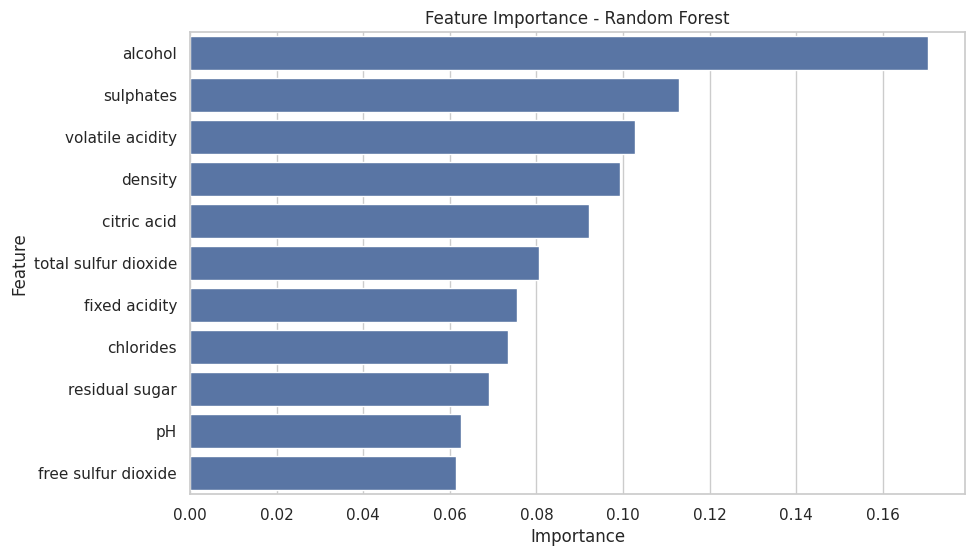

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 15. Make a sample prediction

We take one sample from the test set and predict whether the wine is good quality.

In [19]:
sample = X_test.iloc[[0]]
sample_prediction = rf_model.predict(sample)[0]

print("Wine features:\n")
display(sample)

print("Actual class   :", y_test.iloc[0])
print("Predicted class:", sample_prediction)

Wine features:



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
434,10.4,0.41,0.55,3.2,0.076,22.0,54.0,0.9996,3.15,0.89,9.9


Actual class   : 0
Predicted class: 0


## 16. Summary

In this notebook, we:

- Loaded the Wine Quality dataset directly from a URL
- Explored the dataset and target distribution
- Converted the original quality score into a binary classification target
- Split the data into train and test sets
- Built and evaluated:
  - Logistic Regression
  - Random Forest
- Compared model performance
- Interpreted feature importance

This notebook is useful for revising binary classification on a numeric tabular dataset with no categorical columns.